In [4]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import numpy as np
import math
from sklearn.cluster import KMeans
import gc
import pandas as pd
import random
from scipy.optimize import curve_fit
from sympy import symbols, diff

# Figure 2

In [18]:
cms = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
    "#c5b0d5",  # light purple
    "#c49c94",  # light brown
    "#f7b6d2",  # light pink
    "#c7c7c7",  # light gray
    "#dbdb8d",  # light olive
    "#9edae5",  # light cyan
    "#1f77b4",  # dark blue
    "#ff7f0e",  # dark orange
    "#2ca02c",  # dark green
    "#d62728",  # dark red
    "#9467bd",  # dark purple
    "#8c564b",  # dark brown
    "#e377c2",  # dark pink
    "#7f7f7f",  # dark gray
    "#bcbd22",  # dark olive
    "#17becf",  # dark cyan
]

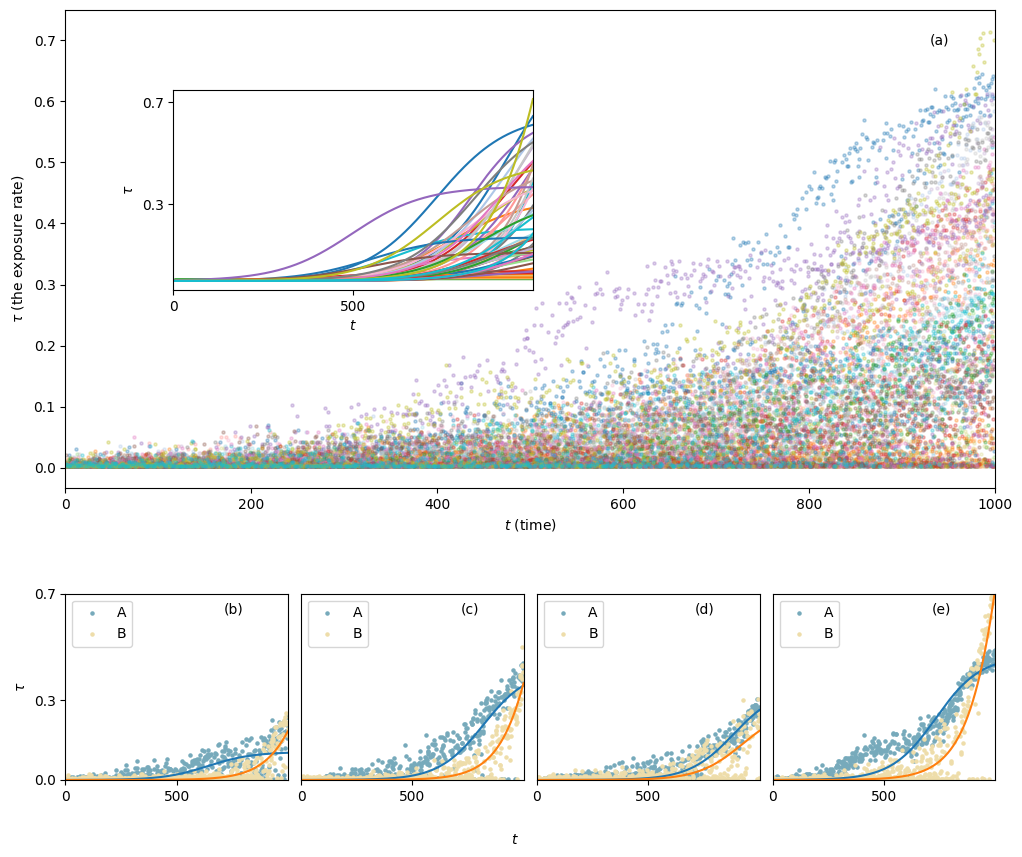

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import os

# 1. Define the generalized logit regression function
def generlized_logit_regression(x, k, b, Q):
    return k / ((1 + Q * np.exp(-b * x))**1/1)

# --- Parameters ---
w = 0.4
alpha = 0.5

# 讀取 CSV 並轉回 Numpy array 格式讓後面的畫圖邏輯無縫接軌
Share = pd.read_csv(f'data/share_time_w{w}_alpha{alpha}.csv').values / 500
Mis_info = pd.read_csv(f'data/mis_info_w{w}_alpha{alpha}.csv').values
Share = np.load(share_path) / 500
Mis_info = np.load(misinfo_path)

# Initialize figure and gridspec layout
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(16, 12)
axs = []

# Main plot (upper section)
axs.append(fig.add_subplot(gs[0:10, :]))
x_axis = np.arange(1000)
color_pale = sns.color_palette("blend:#7AB,#EDA", 2)

# Inset plot configuration
left, bottom, width, height = [0.215, 0.6, 0.3, 0.2]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.set_xticks([0, 500])
ax2.set_yticks([0.3, 0.7])
ax2.set_xlim(0, 1000)
ax2.set_xlabel(r'$t$')
ax2.set_ylabel(r'$\tau$')

# Note: Define your color palette here.
num_lines = np.array(Share).shape[0]

# Plot lines for main and inset plots
for i in range(num_lines):
    axs[0].scatter(x_axis, np.array(Share)[i, :], s=5, alpha=0.3, color=cms[i])
    x_0 = np.where(np.array(Mis_info)[i, :] == 0)[0]
    x_1 = np.where(np.array(Mis_info)[i, :] == 1)[0]
    y_0 = np.array(Share)[i, :][x_0]
    y_1 = np.array(Share)[i, :][x_1]

    params, _ = curve_fit(generlized_logit_regression, x_0, y_0, maxfev=1000, bounds=([-np.inf, 0.01, -np.inf], [np.inf, np.inf, np.inf]))
    k_fit, b_fit, q_fit = params
    y_fit_0 = generlized_logit_regression(x_axis, k_fit, b_fit, q_fit)

    params, _ = curve_fit(generlized_logit_regression, x_1, y_1, maxfev=1000, bounds=([-np.inf, 0.01, -np.inf], [np.inf, np.inf, np.inf]))
    k_fit, b_fit, q_fit = params
    y_fit_1 = generlized_logit_regression(x_axis, k_fit, b_fit, q_fit)

    ax2.plot(x_axis, y_fit_0, color=cms[i])
    ax2.plot(x_axis, y_fit_1, color=cms[i])

# 3. Setup the four bottom subplots
axs.append(fig.add_subplot(gs[12:16, 0:3]))
axs.append(fig.add_subplot(gs[12:16, 3:6]))
axs.append(fig.add_subplot(gs[12:16, 6:9]))
axs.append(fig.add_subplot(gs[12:16, 9:12]))

for ax in axs[2:]:
    ax.set_yticks([])
for ax in axs[1:]:
    ax.set_xticks([0, 500])

# Set random seed for reproducibility in future runs
N = np.random.choice(range(0, 30), 4)
di = np.arange(30)

# Plot the four randomly sampled trajectories
for i in range(1, 5):
    n = N[i-1]

    # Plot state A
    x = np.where(np.array(Mis_info)[di[n], :] == 1)[0]
    y = np.array(Share)[di[n], :][x]
    params, _ = curve_fit(generlized_logit_regression, x, y, maxfev=1000, bounds=([-np.inf, 0.01, -np.inf], [np.inf, np.inf, np.inf]))
    k_fit, b_fit, q_fit = params
    y_fit = generlized_logit_regression(x_axis, k_fit, b_fit, q_fit)

    axs[i].plot(x_axis, y_fit)
    axs[i].scatter(x, y, s=5, alpha=1, color=color_pale[0], label='A')
    axs[i].set_ylim(0, 0.5)

    # Plot state B
    x = np.where(np.array(Mis_info)[di[n], :] == 0)[0]
    y = np.array(Share)[di[n], :][x]
    params, _ = curve_fit(generlized_logit_regression, x, y, maxfev=1000, bounds=([-np.inf, 0.01, -np.inf], [np.inf, np.inf, np.inf]))
    k_fit, b_fit, q_fit = params
    y_fit = generlized_logit_regression(x_axis, k_fit, b_fit, q_fit)

    axs[i].scatter(x, y, s=5, alpha=1, color=color_pale[1], label='B')
    axs[i].plot(x_axis, y_fit)
    axs[i].legend(loc='upper left')
    axs[i].set_ylim(0, 0.7)
    axs[i].set_xlim(0, 1000)
    axs[i].set_xticks([0, 500])

axs[1].set_yticks([0, 0.3, 0.7])

# Configure labels and details
axs[0].set_ylabel(r'$\tau$ (the exposure rate)')
axs[0].set_xlabel(r'$t$ (time)')
axs[0].set_xlim(0, 1000)
axs[1].set_ylabel(r'$\tau$')

# Add subplot titles (a, b, c, d, e)
fig.text(0.5, 0.05, r'$t$', ha='center', va='center')
titles = ['a', 'b', 'c', 'd', 'e']
for i in range(0, 1):
    axs[i].text(0.95, 0.95, f"({titles[i]})", transform=axs[i].transAxes, ha='right', va='top')
for i in range(1, 5):
    axs[i].text(0.8, 0.95, f"({titles[i]})", transform=axs[i].transAxes, ha='right', va='top')
# Display the plot directly in the notebook
plt.show()

# Figure 3


/tmp/ipykernel_39107/3369575792.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap("YlOrRd", 8)
/tmp/ipykernel_39107/3369575792.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_xticklabels(["0", "250", "500", "750", ">1000"])
/tmp/ipykernel_39107/3369575792.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap("YlGn", 8).reversed()
/tmp/ipykernel_39107/3369575792.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplot

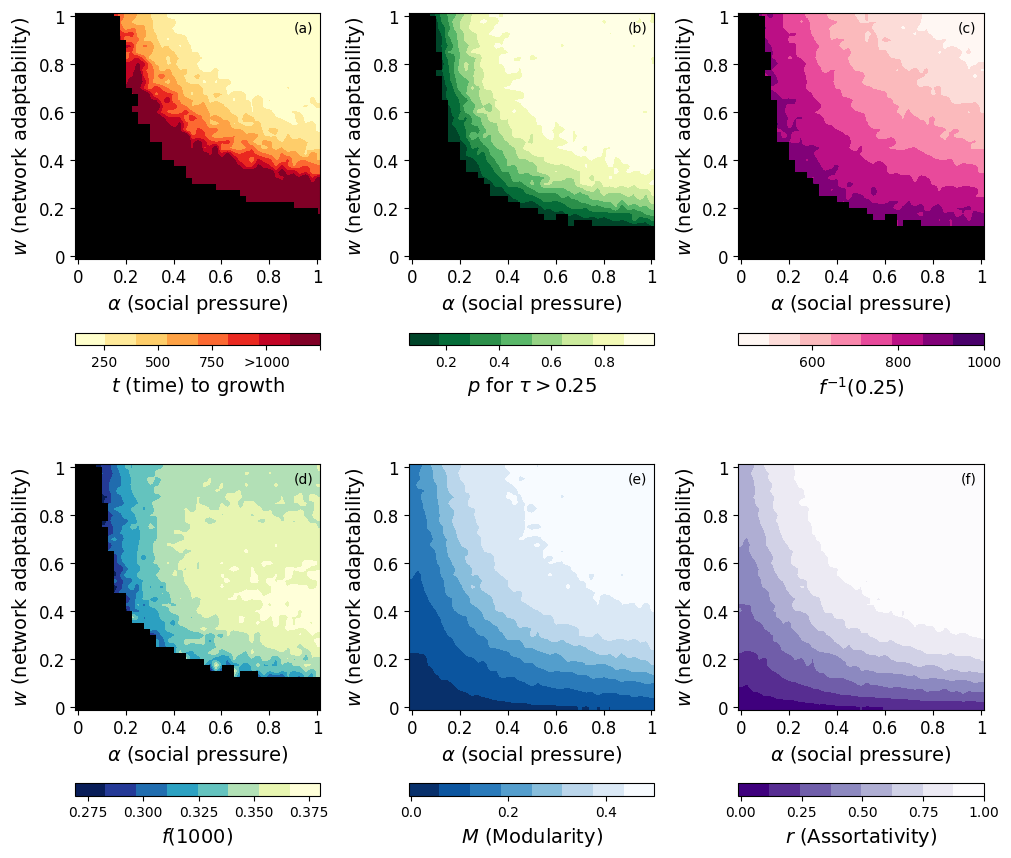

In [47]:
import numpy as np
import matplotlib.pyplot as plt


def plot_simulation_heatmaps(df, df2, df3, df4, df5, df6, figsize=(10, 9)):
    """
    Plot six heatmaps for simulation outcomes across alpha and network adaptability w.

    Parameters
    ----------
    df : array-like
        Time to growth.

    df2 : array-like
        Probability of reaching tau > 0.25.

    df3 : array-like
        Final coverage at t = 1000, f(1000).

    df4 : array-like
        Modularity values.

    df5 : array-like
        Assortativity values.

    df6 : array-like
        Time to reach f(t) = 0.25.

    figsize : tuple
        Figure size.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Figure object.

    ax : numpy.ndarray
        Flattened array of axes.
    """

    fig, ax = plt.subplots(
        2,
        3,
        constrained_layout=True,
        figsize=figsize,
    )
    ax = ax.flatten()

    # Common tick settings
    tick_positions = [0, 8, 16, 24, 32, 40]
    tick_labels = [0, 0.2, 0.4, 0.6, 0.8, 1]

    # ============================================================
    # Panel A: Time to growth
    # ============================================================
    cm = plt.cm.get_cmap("YlOrRd", 8)
    cm.set_bad(color="black")

    # Kept from original code.
    # Note: dff is created but not used in imshow, matching the original figure.
    dff = np.ma.masked_where(df > 1000, df)

    F = ax[0].imshow(
        df,
        cmap=cm,
        interpolation="bilinear",
        vmax=1000,
    )

    ax[0].invert_yaxis()
    ax[0].set_xticks(tick_positions)
    ax[0].set_xticklabels(tick_labels, rotation=0)
    ax[0].set_yticks(tick_positions)
    ax[0].set_yticklabels(tick_labels, rotation=0)
    ax[0].set_xlabel(r"Alpha")
    ax[0].set_ylabel("w (network adaptability)")

    cbar = plt.colorbar(F, orientation="horizontal")
    cbar.ax.invert_yaxis()
    cbar.set_label(r"$t$ (time) to growth", fontsize=14)
    cbar.ax.set_xticklabels(["0", "250", "500", "750", ">1000"])

    # ============================================================
    # Panel B: Probability of reaching tau > 0.25
    # ============================================================
    cm = plt.cm.get_cmap("YlGn", 8).reversed()
    cm.set_bad(color="black")

    dff2 = np.ma.masked_where(df2 < 0.051, df2)

    F2 = ax[1].imshow(
        dff2,
        cmap=cm,
        interpolation="bilinear",
    )

    ax[1].invert_yaxis()
    ax[1].set_xticks(tick_positions)
    ax[1].set_xticklabels(tick_labels, rotation=0)
    ax[1].set_yticks(tick_positions)
    ax[1].set_yticklabels(tick_labels, rotation=0)

    cbar2 = plt.colorbar(F2, orientation="horizontal")
    cbar2.set_label(r"$p$ for $\tau > 0.25$", fontsize=14)

    # ============================================================
    # Panel C: Time to reach f(t) = 0.25
    # ============================================================
    cm = plt.cm.get_cmap("RdPu", 8)
    cm.set_bad(color="black")

    dff6 = np.ma.masked_where(df2 < 0.051, df6)

    F6 = ax[2].imshow(
        dff6,
        cmap=cm,
        interpolation="bilinear",
        vmax=1000,
    )

    ax[2].invert_yaxis()
    ax[2].set_xticks(tick_positions)
    ax[2].set_xticklabels(tick_labels, rotation=0)
    ax[2].set_yticks(tick_positions)
    ax[2].set_yticklabels(tick_labels, rotation=0)

    cbar4 = plt.colorbar(F6, orientation="horizontal")
    cbar4.set_label(r"$f^{-1} (0.25)$", fontsize=14)
    cbar4.ax.invert_yaxis()

    # ============================================================
    # Panel D: Final coverage at t = 1000
    # ============================================================
    cm = plt.cm.get_cmap("YlGnBu", 8).reversed()
    cm.set_bad(color="black")

    dff3 = np.ma.masked_where(df2 < 0.051, df3)

    F3 = ax[3].imshow(
        dff3,
        cmap=cm,
        interpolation="bilinear",
        vmax=0.38,
    )

    ax[3].invert_yaxis()
    ax[3].set_xticks(tick_positions)
    ax[3].set_xticklabels(tick_labels, rotation=0)
    ax[3].set_yticks(tick_positions)
    ax[3].set_yticklabels(tick_labels, rotation=0)

    cbar3 = plt.colorbar(F3, orientation="horizontal")
    cbar3.set_label(r"$f(1000)$", fontsize=14)

    # ============================================================
    # Panel E: Modularity
    # ============================================================
    cm = plt.cm.get_cmap("Blues", 8).reversed()

    F4 = ax[4].imshow(
        df4,
        cmap=cm,
        interpolation="bilinear",
        vmax=0.5,
    )

    ax[4].invert_yaxis()
    ax[4].set_xticks(tick_positions)
    ax[4].set_xticklabels(tick_labels, rotation=0)
    ax[4].set_yticks(tick_positions)
    ax[4].set_yticklabels(tick_labels, rotation=0)
    ax[4].set_xlabel(r"Alpha")
    ax[4].set_ylabel("w")

    cbar5 = plt.colorbar(F4, orientation="horizontal")
    cbar5.set_label(r"$M$ (Modularity)", fontsize=14)

    # ============================================================
    # Panel F: Assortativity
    # ============================================================
    cm = plt.cm.get_cmap("Purples", 8).reversed()
    cm.set_bad(color="black")

    dff5 = np.ma.masked_where(df5 == 0, df5)

    F5 = ax[5].imshow(
        dff5,
        cmap=cm,
        vmax=1,
        interpolation="bilinear",
    )

    ax[5].invert_yaxis()
    ax[5].set_xticks(tick_positions)
    ax[5].set_xticklabels(tick_labels, rotation=0)
    ax[5].set_yticks(tick_positions)
    ax[5].set_yticklabels(tick_labels, rotation=0)
    ax[5].set_xlabel(r"Alpha")
    ax[5].set_ylabel("w")

    cbar6 = plt.colorbar(F5, orientation="horizontal")
    cbar6.set_label(r"$r$ (Assortativity)", fontsize=14)

    # ============================================================
    # Shared axis labels and panel labels
    # ============================================================
    titles = ["a", "b", "c", "d", "e", "f"]

    for i in range(6):
        ax[i].set_xlabel(r"$\alpha$ (social pressure)", fontsize=14)
        ax[i].set_ylabel(r"$w$ (network adaptability)", fontsize=14)
        ax[i].tick_params(axis="both", which="major", labelsize=12)
        ax[i].text(
            0.97,
            0.97,
            f"({titles[i]})",
            transform=ax[i].transAxes,
            ha="right",
            va="top",
        )

    return fig, ax
fig, ax = plot_simulation_heatmaps(df, df2, df3, df4, df5, df6)


# Figure 4

/tmp/ipykernel_39107/700016752.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm1 = plt.cm.get_cmap('pink', 8)
/tmp/ipykernel_39107/700016752.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm2 = plt.cm.get_cmap('copper', 8)
/tmp/ipykernel_39107/700016752.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm3 = plt.cm.get_cmap('bone', 8)


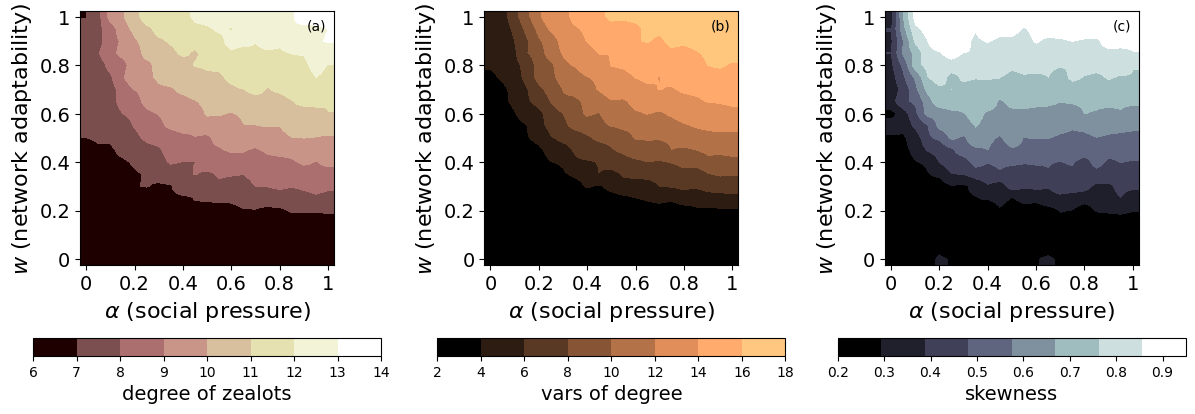

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load pre-aggregated data
df_z = pd.read_csv('data/fig4_zealot_degree.csv', index_col=0)
df_var = pd.read_csv('data/fig4_degree_var.csv', index_col=0)
df_skew = pd.read_csv('data/fig4_degree_skew.csv', index_col=0)

fig, ax = plt.subplots(1, 3, constrained_layout=True, figsize=(12, 4))
ticks = [0, 4, 8, 12, 16, 20]
tick_labels = [0, 0.2, 0.4, 0.6, 0.8, 1]

# Plot 1: Degree of zealots
cm1 = plt.cm.get_cmap('pink', 8)
F1 = ax[0].imshow(df_z, cmap=cm1, vmin=6, vmax=14, interpolation='bilinear')
cbar1 = plt.colorbar(F1, orientation="horizontal", ax=ax[0])
cbar1.set_label(r'degree of zealots', fontsize=14)

# Plot 2: Variance of degree
cm2 = plt.cm.get_cmap('copper', 8)
F2 = ax[1].imshow(df_var, cmap=cm2, vmin=2, vmax=18, interpolation='bilinear')
cbar2 = plt.colorbar(F2, orientation="horizontal", ax=ax[1])
cbar2.set_label(r'vars of degree', fontsize=14)

# Plot 3: Skewness
cm3 = plt.cm.get_cmap('bone', 8)
F3 = ax[2].imshow(df_skew, cmap=cm3, vmin=0.2, vmax=0.95, interpolation='bilinear')
cbar3 = plt.colorbar(F3, orientation="horizontal", ax=ax[2])
cbar3.set_label(r'skewness', fontsize=14)

# Format axes and labels
titles = ['a', 'b', 'c']
for i in range(3):
    ax[i].invert_yaxis()
    ax[i].set_xticks(ticks)
    ax[i].set_xticklabels(tick_labels, rotation=0)
    ax[i].set_yticks(ticks)
    ax[i].set_yticklabels(tick_labels, rotation=0)
    ax[i].set_xlabel(r'$\alpha$ (social pressure)', fontsize=16)
    ax[i].set_ylabel(r'$w$ (network adaptability)', fontsize=16)
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    ax[i].text(0.97, 0.97, f"({titles[i]})", transform=ax[i].transAxes, ha='right', va='top')

plt.show()

# Figure 5

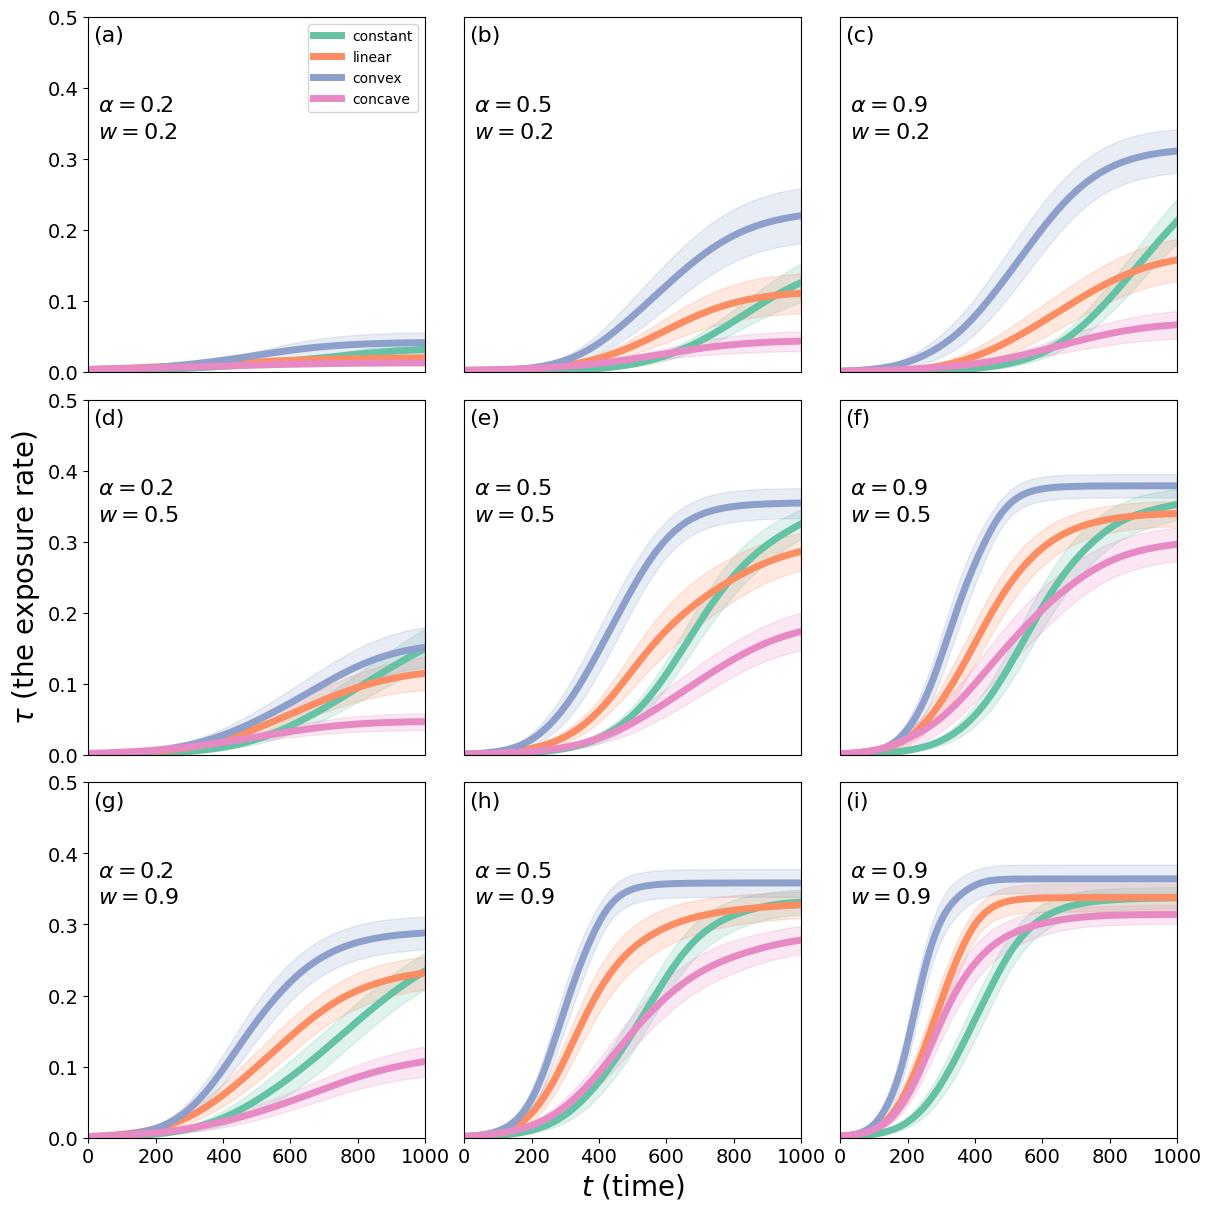

In [55]:
import seaborn as sns

# Load pre-aggregated trajectories
df5 = pd.read_csv('data/fig5_trajectories.csv')

fig, ax = plt.subplots(3, 3, constrained_layout=True, figsize=(12, 12))
ax = ax.flatten()
cm = sns.color_palette("Set2", 4)
dynamics = ['constant2', 'linear2', 'convex2', 'concave2']
dyn_labels = ['constant', 'linear', 'convex', 'concave']

ax_n = 0
for w in [0.2, 0.5, 0.9]:
    for alpha in [0.2, 0.5, 0.9]:

        # Plot each dynamic type
        for idx, dyn in enumerate(dynamics):
            subset = df5[(df5['w'] == w) & (df5['alpha'] == alpha) & (df5['dynamic'] == dyn)]
            mean_vals = subset['mean'].values
            ci_vals = subset['ci'].values
            x_axis = subset['time'].values

            ax[ax_n].plot(x_axis, mean_vals, color=cm[idx], linewidth=5, label=dyn_labels[idx])
            ax[ax_n].fill_between(x_axis, mean_vals - ci_vals, mean_vals + ci_vals, color=cm[idx], alpha=0.2)

        # Add text annotations for parameters
        ax[ax_n].text(0.03, 0.75, fr'$\alpha={alpha}$', transform=ax[ax_n].transAxes, ha='left', va='center', fontsize=16)
        ax[ax_n].text(0.03, 0.675, fr'$w={w}$', transform=ax[ax_n].transAxes, ha='left', va='center', fontsize=16)

        ax[ax_n].set_ylim(0, 0.5)
        ax[ax_n].set_xlim(0, 1000)
        ax[ax_n].set_xticks([])
        ax[ax_n].set_yticks([])
        ax_n += 1

ax[0].legend(markerscale=3.5)
titles = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

for i in range(9):
    ax[i].text(0.015, 0.975, f"({titles[i]})", transform=ax[i].transAxes, ha='left', va='top', fontsize=16)

# X-axis configuration
for i in range(6, 9):
    ax[i].set_xticks([0, 200, 400, 600, 800, 1000])
    ax[i].tick_params(axis='x', labelsize=14)
ax[7].set_xlabel(r'$t$ (time)', fontsize=20)

# Y-axis configuration
for i in [0, 3, 6]:
    ax[i].set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    ax[i].tick_params(axis='y', labelsize=14)
ax[3].set_ylabel(r'$\tau$ (the exposure rate)', fontsize=20)

plt.show()

# Figure 6

/tmp/ipykernel_39107/3812135987.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([0, 1000, 800, 600, 400, 200, 0])
/tmp/ipykernel_39107/3812135987.py:66: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


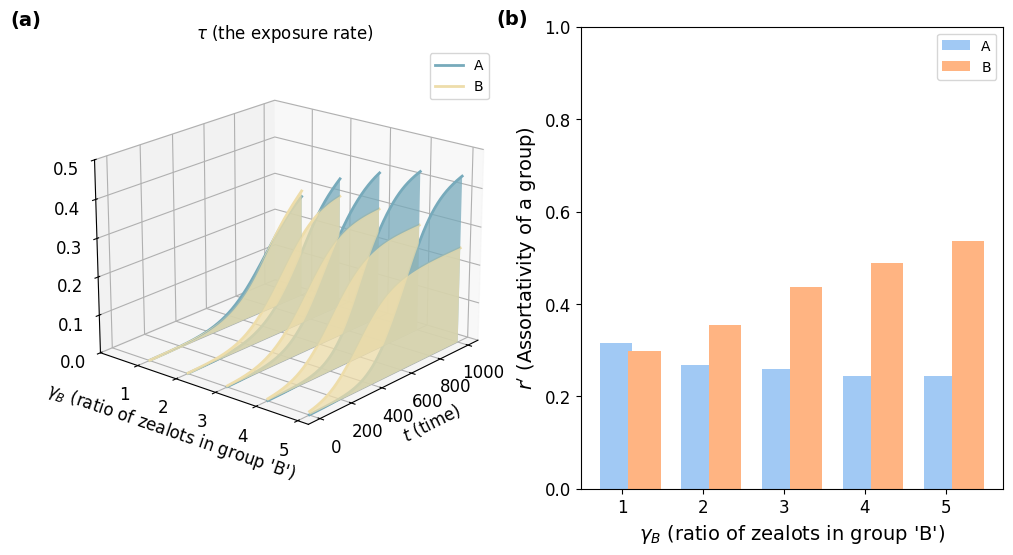

In [58]:
from matplotlib.collections import PolyCollection

# Load pre-aggregated data
df_traj = pd.read_csv('data/fig6_trajectories.csv')
df_assort = pd.read_csv('data/fig6_assortativity.csv')

fig = plt.figure(figsize=(12, 6))
cm_3d = sns.color_palette("blend:#7AB,#EDA", 2)
cm_bar = sns.color_palette("pastel", 2)

# Subplot 1: 3D plot
ax1 = fig.add_subplot(121, projection='3d')
zealot_ratios = [1.0, 2.0, 3.0, 4.0, 5.0]

for z_ratio in zealot_ratios:
    sub0 = df_traj[(df_traj['zealot'] == z_ratio) & (df_traj['state'] == 0)]
    sub1 = df_traj[(df_traj['zealot'] == z_ratio) & (df_traj['state'] == 1)]

    # Draw trajectory lines
    ax1.plot(sub1['time'].values[::-1], [z_ratio]*1000, sub1['value'].values, label='A' if z_ratio==1.0 else "", c=cm_3d[0], linewidth=2)
    ax1.plot(sub0['time'].values[::-1], [z_ratio]*1000, sub0['value'].values, label='B' if z_ratio==1.0 else "", c=cm_3d[1], linewidth=2)

    # Fill Polygons (State 1)
    x1 = list(sub1['time'].values[::-1]) + list(np.arange(1000))
    z1 = list(sub1['value'].values) + list(np.zeros(1000))
    poly1 = PolyCollection([list(zip(x1, z1))], facecolors=[cm_3d[0]], alpha=0.75)
    ax1.add_collection3d(poly1, zs=[z_ratio], zdir='y')

    # Fill Polygons (State 0)
    x0 = list(sub0['time'].values[::-1]) + list(np.arange(1000))
    z0 = list(sub0['value'].values) + list(np.zeros(1000))
    poly0 = PolyCollection([list(zip(x0, z0))], facecolors=[cm_3d[1]], alpha=0.75)
    ax1.add_collection3d(poly0, zs=[z_ratio], zdir='y')

# Configure 3D axes
ax1.legend()
ax1.set_ylabel(r"$\gamma_{B}$ (ratio of zealots in group 'B')", fontsize=12)
ax1.set_xlabel(r'$t$ (time)', fontsize=12)
ax1.set_title(r'$\tau$ (the exposure rate)', fontsize=12)
ax1.view_init(elev=20, azim=40)
ax1.set_xticklabels([0, 1000, 800, 600, 400, 200, 0])
ax1.set_yticks([1, 2, 3, 4, 5])
ax1.set_zlim(0, 0.5)
ax1.set_ylim(0, 5.25)
ax1.text2D(-0.15, 1.05, "(a)", transform=ax1.transAxes, fontsize=14, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=12)

# Subplot 2: Bar plot
ax2 = fig.add_subplot(122)
x_bar = np.array([1, 2, 3, 4, 5])

# Draw bars
ax2.bar(x_bar * 2, df_assort['A1'], label='A', color=cm_bar[0])
ax2.bar(x_bar * 2 + 0.7, df_assort['A0'], label='B', color=cm_bar[1])

# Configure bar plot axes
ax2.set_ylabel(r"$r'$ (Assortativity of a group)", fontsize=14)
ax2.set_xlabel(r"$\gamma_{B}$ (ratio of zealots in group 'B')", fontsize=14)
ax2.set_ylim(0, 1)
ax2.set_xticks(x_bar * 2 + 0.15)
ax2.set_xticklabels([1, 2, 3, 4, 5])
ax2.legend()
ax2.text(-0.2, 1.005, "(b)", transform=ax2.transAxes, fontsize=14, fontweight='bold')
ax2.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()